# Uncertainty Quantification and Active Learning with TabPFN

In this tutorial, we will investigate the uncertainty quantification option for the TabPFN model. 

## Load a test data and a TabPFN mother model

In [ ]:
from mother.ml.models.m_tabpfn import TabPFNRegressorMother

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score, mean_squared_error
from scipy.stats import pearsonr

import pandas as pd
import seaborn as sns
import logging
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import warnings

warnings.warn("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(name)s - %(levelname)s - %(message)s")

/tmp/ipykernel_38529/1867721169.py:18: UserWarning: ignore
  warnings.warn("ignore")


We use a simulated data set for regression using `sklearn.datasets.make_regression`. You can simulate different nosies of data set by changing the `noise` value and compare the quantified uncertainty values. 

In [7]:
X, y = make_regression(
    n_samples=500,  # number of observations
    n_features=10,  # number of features
    bias=10,  # bias term
    noise=50,  # noise level
    n_targets=1,  # number of target values
    random_state=0,  # random seed
    coef=False,  # return coefficients
)

X, y = pd.DataFrame(X), pd.Series(y)
X.shape

(500, 10)

## Quantiles of the prediction 

TabPFN quantifies uncertainty of data points as 'quantiles', which are the quantile values of the target prediction. (Please, note that the uncertanty quantification is only available for regression models.) More details about the uncertainty quantification can be found in [Transformers Can Do Bayesian Inference](https://arxiv.org/abs/2112.10510).

For the toy example, we train the model with 400 data points and quantify the uncertainty of 100 test data points using TabPFN

In [ ]:
model = TabPFNRegressorMother(n_estimators=4)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"{X_train.shape[0]} samples in the train set. {X_test.shape[0]} samples in the test set")

400 samples in the train set. 100 samples in the test set


In [9]:
model.fit(X_train, y_train)

/workspaces/mother-ml/.venv/lib/python3.11/site-packages/tabpfn/regressor.py:490: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  check_cpu_warning(


TabPFNRegressorMother(average_before_softmax=False,
                      categorical_features_indices=None, device='auto',
                      differentiable_input=False, fit_mode='fit_preprocessors',
                      ignore_pretraining_limits=False, inference_config=None,
                      inference_precision='auto', memory_saving_mode='auto',
                      model_path='auto', n_estimators=4, n_jobs=-1,
                      random_state=0, softmax_temperature=1)

`TabPFNRegressorMother` offers the `predict_uncertainty` for the uncertainty quantification. By default, TabPFN returns the 0.25, 0.5, 0.75 quantiles of predicted target values. (You can change the quantiles with the `quantiles` option.) 

The function returns the mean of all quantiles (`mean_predictions`) and the interquartile range (`total_uncertainty`).

When `return_quantiles=True`, the funciton also returns the quantile values, which is a numpy array of (n_quantiles, n_samples).

In [ ]:
y_pred, y_quantiles = model.predict_uncertainty(
    X_test, return_quantiles=True, quantiles=[0.1, 0.25, 0.4, 0.5, 0.75, 0.8, 0.9]
)
print(y_quantiles.shape)
y_pred.head()

(100, 7)


,mean_predictions,knowledge_uncertainty,data_uncertainty,total_uncertainty
481,-105.492134,None,None,68.969688
152,42.967049,None,None,73.294060
96,-127.852371,None,None,66.806267
210,50.671776,None,None,73.084015
433,-15.380236,None,None,70.345291


Here we plot the quantile values of each data point and the correlation between the absolute error and the uncertainty (std of quantiles).

7 bins and 100 data points are plotted.


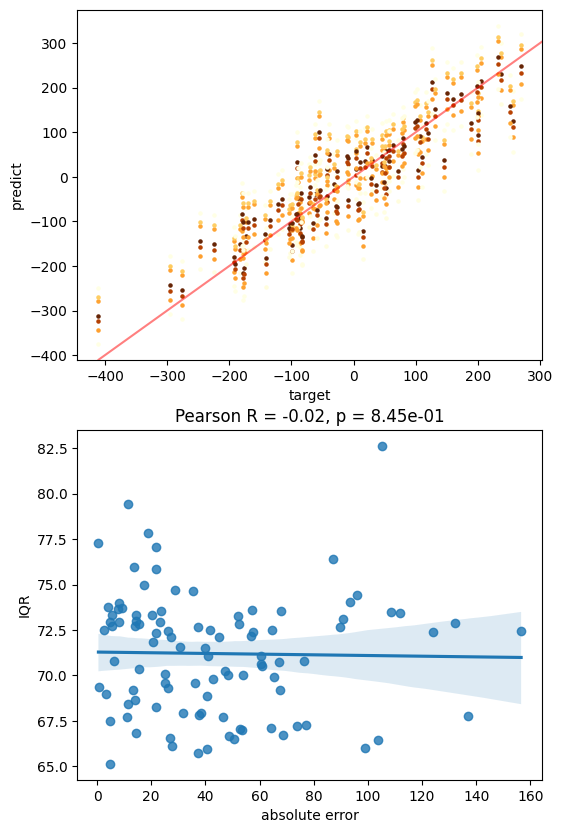

In [79]:
### Code to generate the plot (feel free to ignore)
def plot_regression_uncertainty(ax, target, quantiles, color_multiplier=5) -> None:
    # Calculate the maximum and minimum values in y
    y_max = np.max(quantiles, axis=0)
    y_min = np.min(quantiles, axis=0)

    # Calculate the widths of each quantile bin
    middle = quantiles.shape[0] // 2
    quantile_bin_widths = abs(quantiles - quantiles[middle, :])

    # Normalize the bin widths for a given x
    per_x_normalized_bin_widths = (quantile_bin_widths) / (y_max - y_min)

    # Plotting
    num_bins, num_data_points = per_x_normalized_bin_widths.shape[0], per_x_normalized_bin_widths.shape[1]
    print(f"{num_bins} bins and {num_data_points} data points are plotted.")

    plot_cmap = plt.get_cmap("YlOrBr_r")
    for i in range(num_data_points):
        for j in range(num_bins):
            ax.scatter(
                target.iloc[i],
                quantiles[j, i],
                s=5,
                color=plot_cmap(per_x_normalized_bin_widths[j, i] * color_multiplier),
            )

    ax.axline((0, 0), slope=1, color="red", alpha=0.5)
    ax.set_xlabel("target")
    ax.set_ylabel("predict")


fig, ax = plt.subplots(2, 1, figsize=(6, 10))
plot_regression_uncertainty(ax[0], target=y_test, quantiles=y_quantiles.T, color_multiplier=2)

# plot std and distance from target
y_pred["abs_err"] = abs(y_pred["mean_predictions"] - y_test)
sns.regplot(data=y_pred, x="abs_err", y="total_uncertainty", ax=ax[1])
r, p = pearsonr(y_pred["abs_err"], y_pred["total_uncertainty"])
ax[1].set_title("Pearson R = %.2f, p = %.2e" % (r, p))
ax[1].set_xlabel("absolute error")
ax[1].set_ylabel("IQR")
plt.show()

## Make active learning procedure

In this section, we run a toy example of [active learning](https://en.wikipedia.org/wiki/Active_learning_(machine_learning)). Here we split the data into three parts:

- **Training set**
    
    This is the data set that we are supposed to know the target, so we can use it for training the regressor. The set size increases over epochs since we are supposed to annotate more data points each epoch.
- **Data pool**
    
    These are the data points where we do not know the target value, so we need to select the points where we are most uncertain about and use it for the next model training. 
- **Test set**

    This set also includes data points with known target values, but the set does not change over epochs so that we can calculate the model performance consistently. 

In our active learning set up, we calculate the standard deviation of quantiles of pool data and choose top 5 data points to acquire target values. Then, in the next epoch, the model is trained with the additional data. 

 34%|███▍      | 17/50 [02:35<05:22,  9.76s/it]/workspaces/mother-ml/.venv/lib/python3.11/site-packages/tabpfn/regressor.py:490: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  check_cpu_warning(
 36%|███▌      | 18/50 [02:46<05:21, 10.03s/it]/workspaces/mother-ml/.venv/lib/python3.11/site-packages/tabpfn/regressor.py:490: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  check_cpu_warning(
 38%|███▊      | 19/50 [02:56<05:15, 10.19s/it]/workspaces/mother-ml/.venv/lib/python3.11/site-packages/tabpfn/regressor.py:490: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  check_cpu_warning(
 40%|████      | 20/50 [03:07<05:12, 10.40s/it]/workspaces/mother-ml/.venv/l

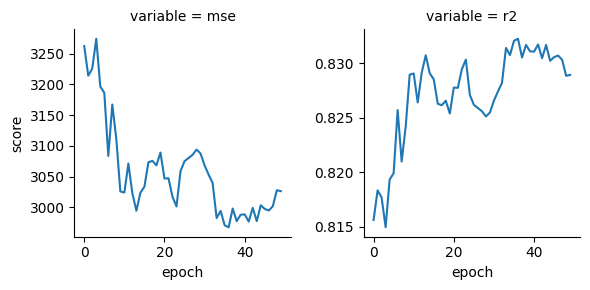

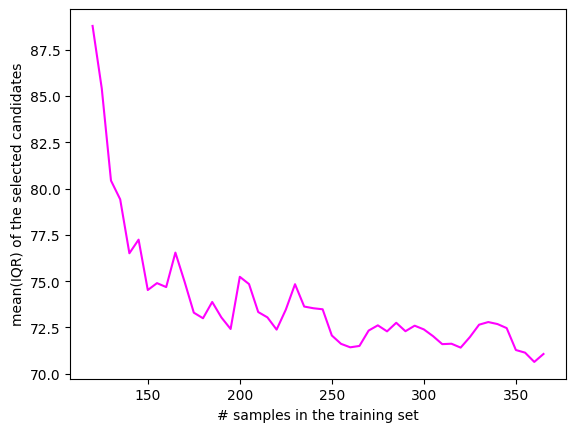

In [ ]:
def active_learning(X_train, X_test, y_train, y_test, n_epochs=50, n_candidate=5):
    # create a pool set
    X_training, X_pool, y_training, y_pool = train_test_split(X_train, y_train, test_size=0.7, random_state=42)

    X_train_cur, y_train_cur = X_training, y_training
    model = TabPFNRegressorMother(n_estimators=4)

    # sanity check
    assert n_candidate * n_epochs <= X_pool.shape[0]
    df_train_epoch = []
    for i in tqdm(range(n_epochs)):
        # train the model
        model.fit(X_train_cur, y_train_cur)

        # calculate test acc
        y_pred_test = model.predict(X_test)
        r2_pred, mse_pred = r2_score(y_test, y_pred_test), mean_squared_error(y_test, y_pred_test)

        # choose candidates to annotate
        uncertainty = model.predict_uncertainty(X_pool)
        max_idx = uncertainty.sort_values(by="total_uncertainty", ascending=False).index[:n_candidate]

        df_train_epoch.append(
            pd.DataFrame(
                {
                    "epoch": [i],
                    "n_train_samples": [X_train_cur.shape[0]],
                    "mean_iqr": uncertainty.loc[max_idx, "total_uncertainty"].mean(),
                    "r2": [r2_pred],
                    "mse": [mse_pred],
                }
            )
        )

        # merge the selected candidates with the training data (fit function always initialise the model)
        X_train_cur = pd.concat([X_train_cur, X_pool.loc[max_idx, :]], axis=0)
        y_train_cur = pd.concat([y_train_cur, y_pool.loc[max_idx]], axis=0)
        X_pool, y_pool = X_pool.drop(index=max_idx), y_pool.drop(index=max_idx)

    df_train_epoch = pd.concat(df_train_epoch).reset_index(drop=True)
    g = sns.FacetGrid(
        data=df_train_epoch.melt(id_vars="epoch", value_vars=["mse", "r2"], value_name="score"),
        col="variable",
        sharey=False,
    )
    g.map(sns.lineplot, "epoch", "score")
    plt.show()

    ax = sns.lineplot(data=df_train_epoch, x="n_train_samples", y="mean_iqr", c="magenta")
    ax.set_xlabel("# samples in the training set")
    ax.set_ylabel("mean(IQR) of the selected candidates")
    plt.show()


active_learning(X_train, X_test, y_train, y_test)

From the first two plots (MSE and R2 scores for the test set), we conclude that the model training improves with active learning. 

The bottom plot shows the average std(quantiles) of selected data points in the data pool. The chosen data sets have a smaller uncertainty over epochs as we keep selecting the most uncertain data points for training. 